1. Import Libraries

In [1]:
import torch
import pandas as pd
import numpy as np

from pathlib import Path
from PIL import Image

import torchvision.transforms as transforms

In [2]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Device:", device)

Device: mps


2. Load finalized datasets

In [3]:
PROCESSED_DIR = Path("../data/processed")

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (29901, 6)
Validation: (6435, 6)
Test: (6459, 6)


3. Inspect an image

In [4]:
sample_path = Path(train_df.iloc[0]["image_path"])
print(sample_path)
print("Exists:", sample_path.exists())

../data/raw/fashion-product-images-small/images/15970.jpg
Exists: True


In [5]:
image = Image.open(sample_path)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (60, 80)
Image mode: RGB


5. Covert images to RGB

In [7]:
image = image.convert("RGB")
print("Image mode:", image.mode)

Image mode: RGB


6. Define image transformations

In [10]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

7. Test the transformation

In [11]:
image_tensor = image_transform(image)
print("Tensor shape:", image_tensor.shape)
print("Tensor dtype:", image_tensor.dtype)
print("Tenosr min:", image_tensor.min().item())
print("Tensor max:", image_tensor.max().item())

Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tenosr min: -2.0836544036865234
Tensor max: 2.640000104904175


8. Small visualization

In [14]:
display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

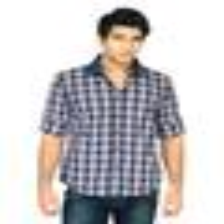

In [16]:
display_image =display_transform(image)
display_image

### Image Loading & Transformation 

- Loaded finalized train/validation/test datasets
- Verified image paths
- Successfully loaded sample image with PIL
- Confirmed RGB format
- Original image size: `60 × 80`
- Resized image to: `224 × 224`
- Converted image to PyTorch tensor
- Tensor shape: `[3, 224, 224]`
- Tensor dtype: `float32`
- Applied ImageNet normalization
- Verified MPS device availability



9. Create the Dataset class

In [25]:
from torch.utils.data import Dataset

class ProductImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)



10. Create a training dataset

In [26]:
train_image_dataset = ProductImageDataset(
    dataframe = train_df,
    transform = image_transform
)

In [27]:
print("Dataset size:", len(train_image_dataset))

Dataset size: 29901


11. Get one sample

In [28]:
image, label = train_image_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)
print("Label dtype:", label.dtype)


Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: tensor(17)
Label dtype: torch.int64


12. Verify several samples

In [32]:
for idx in [0, 100, 1000, 5000, 10000]:
    image, label = train_image_dataset[idx]
    print(
        f"index {idx}: "
        f"shape={image.shape}, "
        f"label={label.item()}"
    )

index 0: shape=torch.Size([3, 224, 224]), label=17
index 100: shape=torch.Size([3, 224, 224]), label=17
index 1000: shape=torch.Size([3, 224, 224]), label=13
index 5000: shape=torch.Size([3, 224, 224]), label=17
index 10000: shape=torch.Size([3, 224, 224]), label=0


13. Create validation and test datasets

In [34]:
val_image_dataset = ProductImageDataset(
    dataframe = val_df,
    transform = image_transform
)

test_image_dataset = ProductImageDataset(
    dataframe = test_df,
    transform = image_transform
)

In [35]:
print("Train datasets:", len(train_image_dataset))
print("Validation datasets:", len(val_image_dataset))
print("Test dataset:", len(test_image_dataset))

Train datasets: 29901
Validation datasets: 6435
Test dataset: 6459


### Image Pipeline

#### Custom PyTorch Dataset 

- Created `ProductImageDataset`
- Loads images using their `image_path`
- Converts images to RGB
- Applies image transformations
- Returns `(image, label)`
- Image tensor shape: `[3, 224, 224]`
- Image dtype: `float32`
- Label dtype: `int64`
- Verified multiple samples
- Created train/validation/test Dataset objects


14. Import DataLoader and Create the DataLoaders

In [36]:
from torch.utils.data import DataLoader

In [38]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_image_dataset,
    batch_size= BATCH_SIZE,
    shuffle = True,
    num_workers = 0
)
val_loader = DataLoader(
    val_image_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 0
)
test_loader = DataLoader(
    test_image_dataset,
    batch_size = BATCH_SIZE,
    shuffle=False,
    num_workers = 0
)


15. Get one batch

In [40]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Label dtype: torch.int64


16. Verify labels

In [41]:
print("Labels:", labels)

Labels: tensor([15,  0,  3,  7,  2,  4, 19, 17, 17, 17, 17,  6,  8, 18, 15, 17, 17, 19,
         2, 17, 14, 17, 19, 12, 17, 18,  6, 11, 17, 17, 18,  2])


In [42]:
print("Unique labels in batch:", torch.unique(labels))

Unique labels in batch: tensor([ 0,  2,  3,  4,  6,  7,  8, 11, 12, 14, 15, 17, 18, 19])


17. Check DataLoader lengths

In [43]:
print("Train batchs:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batchs: 935
Validation batches: 202
Test batches: 202


18. Verify one complete batch can move to MPS

In [44]:
images_mps = images.to(device)
labels_mps = labels.to(device)
print("Images device:", images_mps.device)
print("Labels device:", labels_mps.device)

Images device: mps:0
Labels device: mps:0


19. Verify batch size consistency

In [45]:
print("Image batch size:", images.shape[0])
print("Label batch size:", labels.shape[0])

Image batch size: 32
Label batch size: 32


### Image Dataset Pipeline 

- Loaded train/validation/test datasets
- Created custom `ProductImageDataset`
- Implemented RGB image loading
- Applied 224×224 resizing
- Applied ImageNet normalization
- Converted images to PyTorch tensors
- Created train/validation/test DataLoaders
- Batch size: 32
- Training shuffle enabled
- Validation/test shuffle disabled
- Verified batch shapes and data types
- Verified image-label alignment
- Verified MPS tensor transfer

**Train batches:** 935
**Validation batches:** 202
**Test batches:** 202

20. Create training transform

In [56]:
train_image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness = 0.2,
        contrast = 0.2,
        saturation = 0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

21. Craete evaluation transfrom

In [58]:
eval_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

22. Recreate the datasets

In [61]:
train_image_dataset = ProductImageDataset(
    dataframe = train_df,
    transform = train_image_transform
)

val_image_dataset = ProductImageDataset(
    dataframe= val_df,
    transform = eval_image_transform
)

test_image_dataset = ProductImageDataset(
    dataframe = test_df,
    transform = eval_image_transform
)

23. Recreate DataLoader

In [62]:
train_loader = DataLoader(
    train_image_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_image_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_image_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

24. Verify training batch

In [63]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


24. Verify validation batch

In [64]:
val_images, val_labels = next(iter(val_loader))

print("Validation images:", val_images.shape)
print("Validation labels:", val_labels.shape)

Validation images: torch.Size([32, 3, 224, 224])
Validation labels: torch.Size([32])


25. Verify augmentation actually changes the image

In [65]:
sample_image = Image.open(train_df.iloc[0]["image_path"]).convert("RGB")

augmented_1 = train_image_transform(sample_image)
augmented_2 = train_image_transform(sample_image)
print(
    "Augmented tensors identical:",
    torch.equal(augmented_1, augmented_2)
)

Augmented tensors identical: False


### Image Augmentation & Transform Strategy 

- Created separate training and evaluation transforms
- Added random horizontal flipping
- Added small random rotation
- Added controlled ColorJitter
- Applied ImageNet normalization
- Training uses augmentation
- Validation/test use deterministic transforms
- Verified training batch shape
- Verified validation batch shape
- Confirmed augmentation produces different outputs


26. Inspect Product Text

In [69]:
sample_texts = train_df["productDisplayName"].head(10)

for i, text in enumerate(sample_texts, start = 1):
    print(f"{i}.{text}")

1.Turtle Check Men Navy Blue Shirt
2.Titan Women Silver Watch
3.Manchester United Men Solid Black Track Pants
4.Puma Men Grey T-shirt
5.Inkfruit Mens Chain Reaction T-shirt
6.Jealous 21 Women Purple Shirt
7.Puma Men Pack of 3 Socks
8.Skagen Men Black Watch
9.Fossil Women Black Huarache Weave Belt
10.Fila Men Cush Flex Black Slippers


In [70]:
text_lengths = train_df["productDisplayName"].str.split().str.len()

print("Minimum words:", text_lengths.min())
print("Maximum words:", text_lengths.max())
print("Mean words:", text_lengths.mean())
print("Median words:", text_lengths.median())

Minimum words: 1
Maximum words: 14
Mean words: 5.778067623156416
Median words: 6.0


In [71]:
print(text_lengths.describe())

count    29901.000000
mean         5.778068
std          1.397600
min          1.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         14.000000
Name: productDisplayName, dtype: float64


27. Check the longest product names

In [73]:
longest_indices = (
    train_df["productDisplayName"]
    .str.len()
    .sort_values(ascending=False)
    .head(10)
    .index
)
train_df.loc[
    longest_indices,
    ["productDisplayName", "subCategory"]
]

,productDisplayName,subCategory
5853,U.S. Polo Assn. Men Lavender & White Striped L...,Topwear
21522,Casio Enticer Men Silver-Gold Analogue Multi-D...,Watches
24902,Hanes Women Black Comfortsoft Waistband Cotton...,Bottomwear
9624,Guess Women Mini Triangle White Dial Watch wit...,Watches
18911,Guess Women Mini Triangle White Dial Watch wit...,Watches
7400,Guess Women Mini Quiz White Dial Watch with In...,Watches
8674,Hanes Women Pink Comfortsoft Waistband Cotton ...,Bottomwear
17903,Casio Enticer Men White Dial Multi-Dial Analog...,Watches
8569,Indian Terrain Men Grey & White Checked Linen ...,Topwear
20527,Casio Enticer Women Silver Analogue Multi-Dial...,Watches


28. Check empty/whitespace test

In [74]:
empty_text = (
    train_df["productDisplayName"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty product names:", empty_text)

Empty product names: 0


29. Check text length distribution

In [75]:
print(
    text_lengths.value_counts().sort_index().head(20)
)

productDisplayName
1        5
2        6
3      444
4     4693
5     9002
6     7753
7     4489
8     2339
9      832
10     252
11      61
12      20
13       3
14       2
Name: count, dtype: int64


In [76]:
print(
    "Text with > 32 words:",
    (text_lengths > 32).sum()
)

Text with > 32 words: 0


### Text Pipeline

#### Text Exploration 

- Verified product names
- Minimum words: 1
- Maximum words: 14
- Mean words: 5.78
- Median words: 6
- No empty product names
- No product names exceed 32 words

**Conclusion:**
A small Transformer sequence length is sufficient.



30. Import tokenizer and Load the tokenizer

In [77]:
from transformers import AutoTokenizer

In [79]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 32
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

31. Tokenize one product name

In [83]:
sample_text = train_df.iloc[0]["productDisplayName"]
encoded = tokenizer(
    sample_text,
    padding="max_length",
    truncation = True,
    max_length = MAX_LENGTH,
    return_tensors = "pt"
)

In [84]:
print("Text:", sample_text)
print("Input IDs shape:", encoded["input_ids"].shape)
print("Attention mask shape:", encoded["attention_mask"].shape)

Text: Turtle Check Men Navy Blue Shirt
Input IDs shape: torch.Size([1, 32])
Attention mask shape: torch.Size([1, 32])


32. Inspect the tokens

In [85]:
tokens = tokenizer.convert_ids_to_tokens(
    encoded["input_ids"][0]
)
print(tokens)

['[CLS]', 'turtle', 'check', 'men', 'navy', 'blue', 'shirt', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


33. Inspect the attension mask

In [86]:
print(encoded["attention_mask"])

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])


34. Decode the tokenized text

In [87]:
decoded = tokenizer.decode(
    encoded["input_ids"][0],
    skip_special_tokens = True
)
print("Orignal :", sample_text)
print("Decoded :", decoded)

Orignal : Turtle Check Men Navy Blue Shirt
Decoded : turtle check men navy blue shirt


35. Test a batch of product names

In [89]:
sample_texts = train_df["productDisplayName"].head(8).tolist()

batch_encoded = tokenizer(
    sample_texts,
    padding = "max_length",
    trunction=True,
    max_length = MAX_LENGTH,
    return_tensors = "pt"
)

In [91]:
print(
    "Input IDs shape:",
    batch_encoded["input_ids"].shape
)
print(
    "Attention mask shape:",
    batch_encoded["attention_mask"].shape
)

Input IDs shape: torch.Size([8, 32])
Attention mask shape: torch.Size([8, 32])


36. Check that no text is being truncated

In [92]:
all_texts = train_df["productDisplayName"].tolist()

encoded_all = tokenizer(
    all_texts,
    padding=False,
    truncation=False
)
token_lengths = [
    len(ids)
    for ids in encoded_all["input_ids"]
]
print("Maximum token length: ", max(token_lengths))
print("Texts with > 32 tokens:", sum(
    length > MAX_LENGTH
    for length in token_lengths
))

Maximum token length:  30
Texts with > 32 tokens: 0


### Text Pipeline

#### Step 1 — Text Exploration 
- Examined product-name lengths
- Maximum words: 14
- Mean words: 5.78
- No empty product names

#### Step 2 — Tokenization 
- Transformer: `distilbert-base-uncased`
- `MAX_LENGTH = 32`
- Maximum observed token length: 30
- Texts requiring >32 tokens: 0
- Verified `input_ids`
- Verified `attention_mask`
- Verified batch tokenization
- Verified encode/decode behavior

37. Create MultimmodalProductDataset

In [113]:
class MultimodalProductDataset(Dataset):

    def __init__(
        self, dataframe, image_transform = None,
        tokenizer = None, max_length = 32 ):
        self.dataframe = dataframe.reset_index(drop = True)
        self.image_transform = image_transform
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(
            row["image_path"]
        ).convert("RGB")
        
        if self.image_transform:
            image = self.image_transform(image)

        text = row["productDisplayName"]
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length = self.max_length,
            return_tensors="pt"
        ) 

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        label = torch.tensor(
            row["label"],
            dtype = torch.long
        )

        return {
            "image": image,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label
        }

38. Create the multimodal training dataset

In [115]:
multimodal_train_dataset = MultimodalProductDataset(
    dataframe = train_df,
    image_transform = train_image_transform,
    tokenizer=tokenizer,
    max_length = MAX_LENGTH
)

In [107]:
print("Multimodal train dataset:", len(multimodal_train_dataset))

Multimodal train dataset: 29901


In [117]:
sample = multimodal_train_dataset[0]
print(sample.keys())

dict_keys(['image', 'input_ids', 'attention_mask', 'label'])


In [118]:
print("Image shape:", sample["image"].shape)
print("Image dtype:", sample["image"].dtype)

print("Input IDs shape:", sample["input_ids"].shape)
print("Input IDs dtype:", sample["input_ids"].dtype)

print(
    "Attention mask shape:",
    sample["attention_mask"].shape
)

print(
    "Attention mask dtype:",
    sample["attention_mask"].dtype
)

print("Label:", sample["label"])
print("Label dtype:", sample["label"].dtype)

Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Input IDs shape: torch.Size([32])
Input IDs dtype: torch.int64
Attention mask shape: torch.Size([32])
Attention mask dtype: torch.int64
Label: tensor(17)
Label dtype: torch.int64


In [119]:
sample_text = train_df.iloc[0]["productDisplayName"]

decoded_text = tokenizer.decode(
    sample["input_ids"],
    skip_special_tokens=True
)

print("Original:", sample_text)
print("Decoded :", decoded_text)
print("Label   :", sample["label"].item())
print("Target  :", train_df.iloc[0]["subCategory"])

Original: Turtle Check Men Navy Blue Shirt
Decoded : turtle check men navy blue shirt
Label   : 17
Target  : Topwear


39. Create validation and test multimodal datasets

In [120]:
multimodal_val_dataset = MultimodalProductDataset(
    dataframe=val_df,
    image_transform=eval_image_transform,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

multimodal_test_dataset = MultimodalProductDataset(
    dataframe=test_df,
    image_transform=eval_image_transform,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

In [121]:
print("Train:", len(multimodal_train_dataset))
print("Validation:", len(multimodal_val_dataset))
print("Test:", len(multimodal_test_dataset))

Train: 29901
Validation: 6435
Test: 6459


### Custom Multimodal Dataset 

- Created `MultimodalProductDataset`
- Combined image and text inputs
- Image tensor: `[3, 224, 224]`
- Token IDs: `[32]`
- Attention mask: `[32]`
- Label: `int64`
- Verified text decoding
- Verified label ↔ subcategory mapping
- Created train/validation/test multimodal datasets
- Verified dataset sizes

**Train:** 29,901
**Validation:** 6,435
**Test:** 6,459


40. Create the DataLoaders

In [123]:
from torch.utils.data import DataLoader

BATCH_size = 32

multimodal_train_loader = DataLoader(
    multimodal_train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 0
)

multimodal_val_loader = DataLoader(
    multimodal_val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 0
)

multimodal_test_loader = DataLoader(
    multimodal_test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 0
)

41. Get one training batch

In [126]:
batch = next(iter(multimodal_train_loader))

print(batch.keys())

dict_keys(['image', 'input_ids', 'attention_mask', 'label'])


42. Inspect all batch shapes

In [127]:
print("Images:", batch["image"].shape)
print("Input IDs:", batch["input_ids"].shape)
print("Attention Mask:", batch["attention_mask"].shape)
print("Labels:", batch["label"].shape)

Images: torch.Size([32, 3, 224, 224])
Input IDs: torch.Size([32, 32])
Attention Mask: torch.Size([32, 32])
Labels: torch.Size([32])


In [128]:
print("Image dtype:", batch["image"].dtype)
print("Input IDs dtype:", batch["input_ids"].dtype)
print("Attention mask dtype:", batch["attention_mask"].dtype)
print("Labels dtype:", batch["label"].dtype)

Image dtype: torch.float32
Input IDs dtype: torch.int64
Attention mask dtype: torch.int64
Labels dtype: torch.int64


43. Move the complete batch to MPS

In [129]:
batch_mps = {
    key: value.to(device)
    for key, value in batch.items()
}

for key, value in batch_mps.items():
    print(f"{key}: {value.device}")

image: mps:0
input_ids: mps:0
attention_mask: mps:0
label: mps:0


In [130]:
print("Train batches:", len(multimodal_train_loader))
print("Validation batches:", len(multimodal_val_loader))
print("Test batches:", len(multimodal_test_loader))

Train batches: 935
Validation batches: 202
Test batches: 202


In [131]:
batch_text = tokenizer.decode(
    batch["input_ids"][0],
    skip_special_tokens=True
)

batch_label = batch["label"][0].item()

print("Decoded text:", batch_text)
print("Label:", batch_label)

Decoded text: wildcraft unisex orange alpinist 55 backpack
Label: 0


In [133]:
import json

with open("../data/processed/label_mapping.json", "r") as f:
    label_mapping = json.load(f)


In [134]:
label_to_category = {
    value: key
    for key, value in label_mapping.items()
}

print(
    "Category:",
    label_to_category[batch_label]
)

Category: Bags


### Text & Multimodal Dataset Pipeline 

#### Text
- Explored product names
- Selected `distilbert-base-uncased`
- Selected `MAX_LENGTH = 32`
- Verified maximum token length: 30
- Created tokenizer pipeline
- Verified `input_ids`
- Verified `attention_mask`

#### Multimodal Dataset
- Created `MultimodalProductDataset`
- Combined image + text + label
- Verified image tensor
- Verified token tensors
- Verified label alignment

#### DataLoaders
- Created train/validation/test multimodal DataLoaders
- Batch size: 32
- Train batches: 935
- Validation batches: 202
- Test batches: 202
- Verified complete batches on MPS

44. Validate labels

In [136]:
NUM_CLASSES = 20

for name, dataframe in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    invalid_labels = ~dataframe["label"].between(
        0, NUM_CLASSES -1
    )
    print(f"{name} inavlid labels:", invalid_labels.sum())

Train inavlid labels: 0
Validation inavlid labels: 0
Test inavlid labels: 0


45. Verify all 20 classes in every split

In [138]:
for name, dataframe in [
    ("Train", train_df), ("Validation", val_df), ("Test", test_df)
]:
    classes = sorted(dataframe["label"].unique())
    print(f"{name} classes:", classes)
    print(f"{name} class count:", len(classes))

Train classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Train class count: 20
Validation classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Validation class count: 20
Test classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Test class count: 20


46. Verify DataLoader iteration

In [139]:
for batch_number, batch in enumerate(multimodal_train_loader):
    if batch_number >= 5:
        break

    print(
        f"Batch {batch_number}:"
        f"images={batch['image'].shape}, "
        f"input_ids={batch['input_ids'].shape}, "
        f"mask={batch['attention_mask'].shape}, "
        f"labels={batch['label'].shape}"
    )

Batch 0:images=torch.Size([32, 3, 224, 224]), input_ids=torch.Size([32, 32]), mask=torch.Size([32, 32]), labels=torch.Size([32])
Batch 1:images=torch.Size([32, 3, 224, 224]), input_ids=torch.Size([32, 32]), mask=torch.Size([32, 32]), labels=torch.Size([32])
Batch 2:images=torch.Size([32, 3, 224, 224]), input_ids=torch.Size([32, 32]), mask=torch.Size([32, 32]), labels=torch.Size([32])
Batch 3:images=torch.Size([32, 3, 224, 224]), input_ids=torch.Size([32, 32]), mask=torch.Size([32, 32]), labels=torch.Size([32])
Batch 4:images=torch.Size([32, 3, 224, 224]), input_ids=torch.Size([32, 32]), mask=torch.Size([32, 32]), labels=torch.Size([32])


47. Check the final incomplete batch

In [140]:
last_batch = None

for batch in multimodal_train_loader:
    last_batch = batch

print("Final train batch:")
print("Images:", last_batch["image"].shape)
print("Input IDs:", last_batch["input_ids"].shape)
print("Attention Mask:", last_batch["attention_mask"].shape)
print("Labels:", last_batch["label"].shape)

Final train batch:
Images: torch.Size([13, 3, 224, 224])
Input IDs: torch.Size([13, 32])
Attention Mask: torch.Size([13, 32])
Labels: torch.Size([13])


48. Check image readability

In [143]:
from PIL import Image

def check_images(dataframe):
    bad_images = []

    for image_path in dataframe["image_path"]:
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            bad_images.append(image_path)

    return bad_images

In [144]:
bad_train = check_images(train_df)
bad_val = check_images(val_df)
bad_test = check_images(test_df)

print("Bad train images:", len(bad_train))
print("Bad validation images:", len(bad_val))
print("Bad test images:", len(bad_test))

Bad train images: 0
Bad validation images: 0
Bad test images: 0


In [145]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print(
    "Total:",
    len(train_df) + len(val_df) + len(test_df)
)

Train: 29901
Validation: 6435
Test: 6459
Total: 42795


# Phase 2 — Data Preparation 

## Environment
- PyTorch + Torchvision
- Hugging Face Transformers
- Apple MPS acceleration

## Image Pipeline
- RGB conversion
- 224×224 resizing
- ImageNet normalization
- Training augmentation
- Custom PyTorch Dataset
- DataLoader with batch size 32

## Text Pipeline
- `distilbert-base-uncased`
- `MAX_LENGTH = 32`
- Tokenization
- `input_ids`
- `attention_mask`

## Multimodal Dataset
Each sample contains:
- `image`
- `input_ids`
- `attention_mask`
- `label`

## Validation
- All labels valid
- All 20 classes present in every split
- DataLoader successfully iterated
- Final train batch verified
- Corrupted images: 0

## Final Dataset
Train: 29,901
Validation: 6,435
Test: 6,459
Total: 42,795